# 16. Spatio-Temporal Graph Transformer Regression Kriging


**Dataset:** California PM2.5 monitoring network, 2025 (`data/CA_pm25_2025.csv`)

**Prediction grid:** Classical space-time Ordinary Kriging reference (`data/CA_pm25_grid_predictions.csv`)

**Target:** Monthly mean PM2.5 (µg/m³)

**Library:** `pygstat` v0.1.0 — `STTN`, `GMAN`, `STGTNRegressionKriging`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the California PM2.5 Panel](#4-load-and-explore-the-california-pm25-panel)
5. [Spatial $k$-NN Graph and Positional Encoding](#5-spatial-k-nn-graph-and-positional-encoding)
6. [Hold-Out Station Split](#6-hold-out-station-split)
7. [Fit STTN and GMAN](#7-fit-sttn-and-gman)
8. [Training Curves](#8-training-curves)
9. [Validate on Held-Out Stations](#9-validate-on-held-out-stations)
10. [Residual Variograms](#10-residual-variograms)
11. [Predict on the California Grid](#11-predict-on-the-california-grid)
12. [Compare with Classical ST Kriging](#12-compare-with-classical-st-kriging)
13. [Map Predictions](#13-map-predictions)
14. [CPU vs GPU STTN Timing](#14-cpu-vs-gpu-sttn-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)



***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** with **ordinary kriging of the residuals**. At location $\mathbf{s}$ and time $t$,

$$
Z(\mathbf{s}, t) = \hat{m}(\mathbf{s}, t) + \hat{e}(\mathbf{s}, t)
$$

where $\hat{m}(\mathbf{s}, t)$ is the trend prediction and $\hat{e}(\mathbf{s}, t)$ is the kriged residual. [Tutorial 15](15_kriging_STGNN.ipynb) uses a *recurrent* GNN (GRU gates built from graph convolutions). This notebook uses **spatio-temporal graph Transformers**: a **spatial attention** layer lets every node attend to its $k$-NN neighbors at each month, and a **temporal attention** layer lets every node attend across its own time steps. Residuals are then kriged independently per month — the same RK recipe as `TGCN`/`DCRNN` and `ConvLSTM`.

This is the attention-based counterpart of [Tutorial 15 (ST-GNN)](15_kriging_STGNN.ipynb) and the deep-learning counterpart of [Tutorial 13 (Spatio-Temporal Kriging)](13_krigingST.ipynb). The validation protocol matches `tests/test_kriging_STGTN.py` (same seed, same 25 held-out stations, same classical ST-kriging grid).

| Step | What we do |
|------|------------|
| Data | Load daily CA PM2.5 for 2025 (163 stations); aggregate to monthly means; project to California Albers (EPSG:3310, meters) |
| Graph | Build a directed $k$-NN graph of stations (`k_neighbors=8`); inject sinusoidal time encodings |
| Split | Hold out **25 complete stations** entirely (seed=0), matching `pygstat.krigeST` and the STGTN unit tests |
| Fit | Fit `STTN` and `GMAN` (`hidden_dim=32`, `n_heads=4`, 2 layers) on the remaining stations, with per-month residual ordinary kriging |
| Validation | Predict every held-out station-month; report RMSE, MAE, $R^2$ vs a naive-mean baseline |
| Grid | Predict at the 5 km California grid used by classical ST kriging; correlate month-by-month with `CA_pm25_grid_predictions.csv` |
| Mapping | Draw monthly PM2.5 surfaces, kriging standard error, and a side-by-side comparison with the classical reference |
| CPU / GPU | Time `STTN.fit`+`predict` on CPU vs GPU using **sgsim** CA-like PM2.5 ($n=8{,}400$) |

By the end you will have two validated graph-Transformer interpolators, a monthly PM2.5 surface for California in 2025, and a CPU vs GPU timing of STTN training+inference on an SGS-simulated panel.

### ST-GTN trend models in this notebook

`pygstat` wraps two published graph Transformer blocks. Each follows the same RK recipe. Graphs are $k$-nearest-neighbor graphs of the coordinates (`scipy.spatial.cKDTree`); spatial attention uses scatter-softmax (`index_add_`); temporal attention is stock `nn.MultiheadAttention` — no `torch_geometric` dependency.

| Class | Architecture | How space and time are combined |
|-------|-------------|-------------------------------|
| `STTN` | Spatial-Temporal Transformer Network (Xu et al., 2020) | Spatial Transformer block, then temporal Transformer block (sequential) |
| `GMAN` | Graph Multi-Attention Network (Zheng et al., 2020) | Spatial and temporal attention **in parallel**, fused by a learned gate |
| `STGTNRegressionKriging` | Shared engine | `block_type='sttn'` or `'gman'`; `STTN`/`GMAN` are thin aliases |

Attention has no inherent sense of order, unlike the GRU cells in Tutorial 15, so a **sinusoidal positional encoding** of the month index (Vaswani et al., 2017) is added to every node's input. Both models are inductive at prediction time: new locations attach only to *training* nodes.



***
## 2. Mathematical Formulation

The target $Z(\mathbf{s}, t)$ at location $\mathbf{s}$ and time $t$ is

$$
Z(\mathbf{s}, t) = \mu(\mathbf{s}, t) + \varepsilon(\mathbf{s}, t)
$$

where $\mu(\mathbf{s}, t)$ is a **deterministic spatio-temporal trend** (the graph Transformer) and $\varepsilon(\mathbf{s}, t)$ is a **zero-mean, spatially autocorrelated residual**, kriged independently at each time step.

### 2.1 Spatial graph and inputs

Given $n$ stations with coordinates $\mathbf{s}_i = (x_i, y_i)$, a directed $k$-nearest-neighbor graph $\mathcal{G}=(V,E)$ connects each node to its $k$ nearest *other* stations. At prediction time, each *new* location is attached with $k$ edges **into the training graph only** — no new-to-new edges.

Every node's input at time $t$ is the two-channel vector $[m_{i,t}\, z_{i,t},\; m_{i,t}]$ (IGNNK-style masking; Wu et al., 2021), linearly embedded to dimension $d$ and added to a sinusoidal positional encoding $\mathrm{PE}(t)\in\mathbb{R}^d$:

$$
h_{i,t}^{(0)} = W_{\mathrm{in}}[m_{i,t}\, z_{i,t},\; m_{i,t}] + \mathrm{PE}(t).
$$

### 2.2 Graph multi-head attention

Spatial attention is a graph Transformer layer (Dwivedi & Bresson, 2020): for each destination node, scaled dot-product attention is restricted to its incoming $k$-NN edges and softmax-normalized **per head** via scatter-softmax,

$$
\alpha_{ij}^{(h)} = \mathrm{softmax}_{j\in\mathcal{N}(i)}\!\left(\frac{q_i^{(h)\top} k_j^{(h)}}{\sqrt{d_h}}\right), \qquad
h_i = W_O \big\Vert_{h=1}^{H} \sum_{j\in\mathcal{N}(i)}\alpha_{ij}^{(h)} v_j^{(h)}.
$$

This is the multi-head, learned Query/Key generalization of the single learned-scalar attention in Tutorial 7.5's `GATConv`.

Temporal attention is an unmodified Transformer self-attention over the $T$ months of a single node (`nn.MultiheadAttention` with `batch_first=True`).

### 2.3 STTN block (Xu et al., 2020)

One STTN layer applies a spatial Transformer block (graph attention independently at each time step) **then** a temporal Transformer block (self-attention across time, independently per node). Each is a standard pre-residual, post-norm sub-layer with its own feed-forward network:

$$
H \leftarrow \mathrm{LN}\big(H + \mathrm{FF}\big(\mathrm{LN}\big(H + \mathrm{Attn}(H)\big)\big)\big).
$$

### 2.4 GMAN block (Zheng et al., 2020)

GMAN computes spatial and temporal attention **in parallel** from the same input, then fuses them with a learned gate

$$
g = \sigma\big(W[h_{\mathrm{spatial}}; h_{\mathrm{temporal}}]\big), \qquad
h = g \odot h_{\mathrm{spatial}} + (1-g)\odot h_{\mathrm{temporal}}.
$$

That gate, rather than sequential alternation, is GMAN's difference from STTN.

A shared linear head maps the top-layer hidden state at each $(i,t)$ to a scalar trend $\hat{m}(\mathbf{s}_i, t)$.

### 2.5 IGNNK-style masking and residual kriging

Training hides a validation subset of stations entirely, plus a random fraction `mask_ratio` of the remaining observed (station, month) cells, and reconstructs them from the rest of the space-time graph. After fitting, out-of-fold reconstructions yield residuals $e_i(t)=Z(\mathbf{s}_i,t)-\hat{m}(\mathbf{s}_i,t)$. A spherical variogram is fit independently at each month, and ordinary kriging of those residuals is added back:

$$
\hat{Z}(\mathbf{s}_0, t) = \hat{m}(\mathbf{s}_0, t) + \sum_{i \in \mathcal{O}_t} \lambda_i(t)\, e_i(t).
$$


***
## 3. Python Setup

`STTN(..., device=...)` (and the other PyTorch ST models) send the network to:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | CUDA when this PyTorch build has kernels for the attached GPU. Falls back to CPU otherwise. |
| `'cuda'` | Force GPU. |
| `'cpu'` | Always CPU. |

This notebook probes CUDA once and stores the result in `DEVICE`. Fits below pass `device=DEVICE`. **§14** times `device='cpu'` against `device='cuda'` on an **SGS-simulated** CA-like PM2.5 panel with $n > 5{,}000$ space-time observations. Residual ordinary kriging is skipped in that section (`krige_residuals=False`) so the times isolate the neural net, not the CPU-only kriging solve.

Install extras with `pip install pygstat[pytorch]`.


In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

# pygstat optionally imports TensorFlow for DeepRegressionKrigingTF.
# Loading that stack in the same process as PyTorch can crash; keep TF out.
sys.modules.setdefault("tensorflow", None)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pygstat import GMAN, STGTNRegressionKriging, STTN, load_ca_pm25_panel, sgsim
from pygstat.kriging_STGTN import (
    GatedFusionBlock,
    GraphMultiHeadAttention,
    SpatialTemporalBlock,
    _knn_edges,
    _sinusoidal_positional_encoding,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

DATA_DIR = Path("..") / "data"
MONTH_NAMES = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

print("torch version :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cpu"
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    print("GPU           :", torch.cuda.get_device_name(0), f"(sm_{major}{minor})")
    # This wheel ships kernels for sm_75+; older cards fall back to CPU.
    if (major, minor) >= (7, 5):
        DEVICE = "cuda"
    else:
        print("GPU compute capability is below sm_75; using CPU")
print("Using device :", DEVICE)


torch version : 2.14.0+cu126
CUDA available: True
GPU           : NVIDIA GeForce RTX 2080 Ti (sm_75)
Using device : cuda



***
## 4. Load and Explore the California PM2.5 Panel

`data/CA_pm25_2025.csv` holds daily PM2.5 (µg/m³) at 163 California air-quality stations through 2025. `load_ca_pm25_panel` aggregates daily readings to **monthly station means** and projects coordinates from lat/long (EPSG:4326) to **California Albers Equal Area (EPSG:3310, meters)**.

The companion file `data/CA_pm25_grid_predictions.csv` is the classical space-time Ordinary Kriging surface for the same panel (`scripts/predict_ca_pm25_grid.py` via `pygstat.krigeST`) — the reference this tutorial compares against, and the same file used by `tests/test_kriging_STGTN.py`.


In [2]:
raw = pd.read_csv(DATA_DIR / "CA_pm25_2025.csv")
print(f"Daily file : {raw.shape[0]:,} rows, {raw['Site ID'].nunique()} stations")
print(f"Date range : {raw['Date'].min()} -> {raw['Date'].max()}")
print("Columns    :", list(raw.columns))
raw.head()


Daily file : 59,566 rows, 163 stations
Date range : 01/01/2025 -> 12/31/2025
Columns    : ['Site ID', 'State', 'County', 'Lat', 'Long', 'Date', 'Daily_PM2.5_ug_m3', 'Daily_AQI']


,Site ID,State,County,Lat,Long,Date,Daily_PM2.5_ug_m3,Daily_AQI
0,60010009,California,Alameda,37.743,-122.170,01/01/2025,12.200,57
1,60010009,California,Alameda,37.743,-122.170,01/02/2025,9.200,51
2,60010009,California,Alameda,37.743,-122.170,01/03/2025,7.700,43
3,60010009,California,Alameda,37.743,-122.170,01/04/2025,5.800,32
4,60010009,California,Alameda,37.743,-122.170,01/05/2025,6.700,37


In [3]:
panel = load_ca_pm25_panel(DATA_DIR / "CA_pm25_2025.csv")
wide = panel.pivot(index="site_id", columns="month", values="pm25").sort_index()
coords = (
    panel[["site_id", "x", "y"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index][["x", "y"]].to_numpy()
)
values = wide.to_numpy()
site_ids = wide.index.to_numpy()
latlon = (
    panel[["site_id", "lat", "lon"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index]
)

n_missing = int(np.isnan(values).sum())
counts = (~np.isnan(values)).sum(axis=1)
complete = np.flatnonzero(counts == 12)

print(f"Monthly panel : {len(panel):,} site-month rows")
print(f"Stations      : {len(coords)}  (coords {coords.shape}, values {values.shape})")
print(f"Complete 12-mo: {len(complete)} / {len(coords)}")
print(f"Missing cells  : {n_missing} station-months (NaN)")
print(
    f"PM2.5 (ug/m3) : mean={np.nanmean(values):.2f}  "
    f"min={np.nanmin(values):.2f}  max={np.nanmax(values):.2f}"
)
print(f"Albers x      : {coords[:, 0].min():.0f} .. {coords[:, 0].max():.0f} m")
print(f"Albers y      : {coords[:, 1].min():.0f} .. {coords[:, 1].max():.0f} m")
panel.head()


Monthly panel : 1,935 site-month rows
Stations      : 163  (coords (163, 2), values (163, 12))
Complete 12-mo: 156 / 163
Missing cells  : 21 station-months (NaN)
PM2.5 (ug/m3) : mean=7.01  min=-0.50  max=39.05
Albers x      : -352817 .. 424125 m
Albers y      : -602223 .. 423150 m


,site_id,month,pm25,lat,lon,x,y
0,60010009,0,6.948,37.743,-122.170,-190936.009,-28196.821
1,60010009,1,3.736,37.743,-122.170,-190936.009,-28196.821
2,60010009,2,3.681,37.743,-122.170,-190936.009,-28196.821
3,60010009,3,5.323,37.743,-122.170,-190936.009,-28196.821
4,60010009,4,6.922,37.743,-122.170,-190936.009,-28196.821


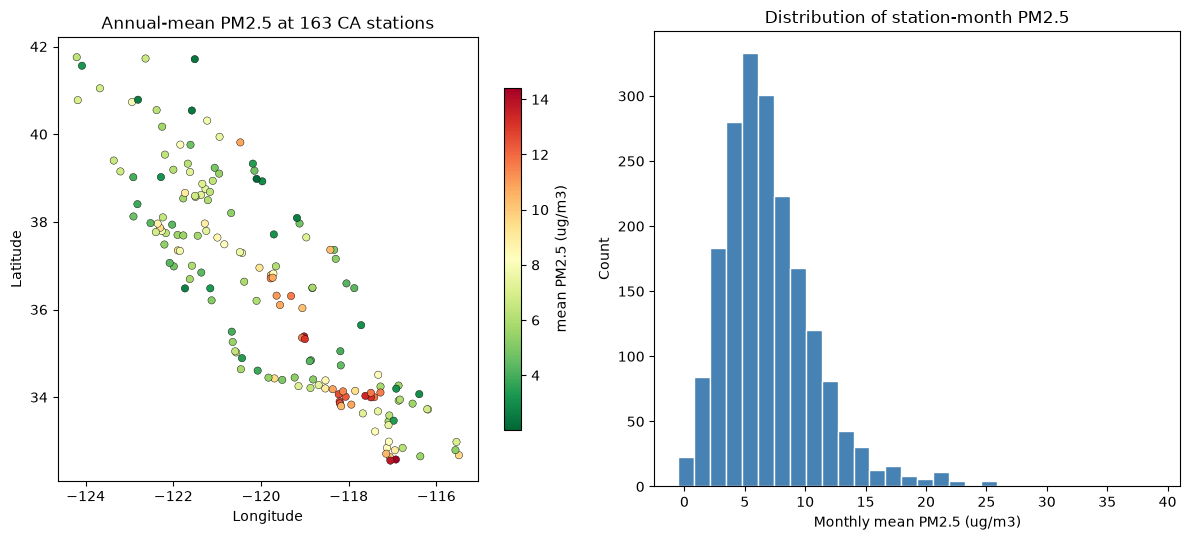

In [4]:
mean_pm = np.nanmean(values, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

sc = axes[0].scatter(
    latlon["lon"], latlon["lat"], c=mean_pm,
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3,
)
plt.colorbar(sc, ax=axes[0], label="mean PM2.5 (ug/m3)", shrink=0.75)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Annual-mean PM2.5 at 163 CA stations")
axes[0].set_aspect("equal", adjustable="box")

axes[1].hist(values[~np.isnan(values)], bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Monthly mean PM2.5 (ug/m3)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of station-month PM2.5")
plt.tight_layout()
plt.show()


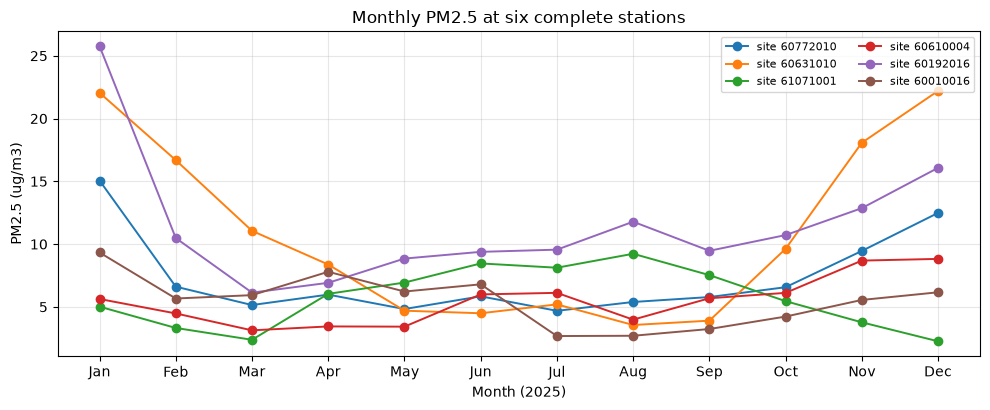

In [5]:
rng_plot = np.random.default_rng(1)
demo_idx = rng_plot.choice(complete, size=6, replace=False)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i in demo_idx:
    ax.plot(range(12), values[i], marker="o", linewidth=1.4, label=f"site {int(site_ids[i])}")
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_xlabel("Month (2025)")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Monthly PM2.5 at six complete stations")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Annual-mean PM2.5 is highest in the Central Valley and the South Coast and lowest along the north coast and Sierra. The six example series show a shared seasonal pattern plus station-to-station differences — spatial attention over the $k$-NN graph and temporal attention over the 12 months are the two mechanisms that capture them.



***
## 5. Spatial $k$-NN Graph and Positional Encoding

Before fitting, look at the two ingredients the Transformer actually sees: the station graph, and the sinusoidal encoding that gives attention a sense of month order. `_knn_edges` builds each station's 8 nearest other stations (no self-loops). At prediction time the same constructor attaches *query* points to training nodes only.


Training graph : 163 nodes, 1304 directed edges
edge_index     : (2, 1304)  (expected (2, 1304))
Self-loops     : False
Edge length    : median=44.8 km, max=224.5 km
Query edges    : sources all in training (True), destinations all query (True)


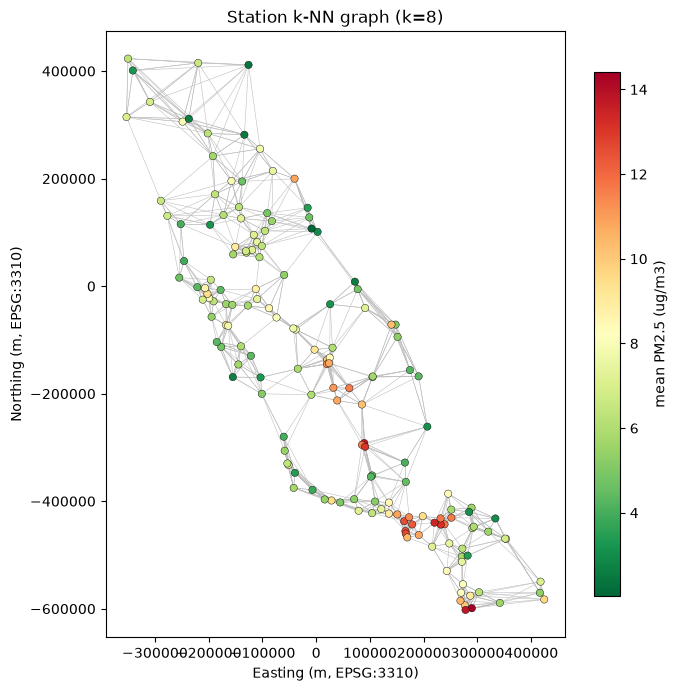

In [6]:
K_NEIGHBORS = 8
edge_index, edge_dist = _knn_edges(coords, k=K_NEIGHBORS)
src, dst = edge_index.numpy()
print(f"Training graph : {len(coords)} nodes, {edge_index.shape[1]} directed edges")
print(f"edge_index     : {tuple(edge_index.shape)}  (expected (2, {len(coords) * K_NEIGHBORS}))")
print(f"Self-loops     : {(src == dst).any()}")
print(f"Edge length    : median={np.median(edge_dist)/1000:.1f} km, max={edge_dist.max()/1000:.1f} km")

rng_q = np.random.default_rng(1)
query = rng_q.uniform(coords.min(0), coords.max(0), size=(6, 2))
q_edge, _ = _knn_edges(coords, k=4, query_coords=query)
q_src, q_dst = q_edge.numpy()
print(
    f"Query edges    : sources all in training ({(q_src < len(coords)).all()}), "
    f"destinations all query ({(q_dst >= len(coords)).all()})"
)

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(
    np.vstack([coords[src, 0], coords[dst, 0]]),
    np.vstack([coords[src, 1], coords[dst, 1]]),
    color="0.75", linewidth=0.4, zorder=1,
)
sc = ax.scatter(
    coords[:, 0], coords[:, 1], c=np.nanmean(values, axis=1),
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3, zorder=2,
)
plt.colorbar(sc, ax=ax, shrink=0.7, label="mean PM2.5 (ug/m3)")
ax.set_xlabel("Easting (m, EPSG:3310)")
ax.set_ylabel("Northing (m, EPSG:3310)")
ax.set_title(f"Station k-NN graph (k={K_NEIGHBORS})")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


PE shape : (12, 32)  (months x hidden_dim)
PE range  : [-1.000, 1.000]


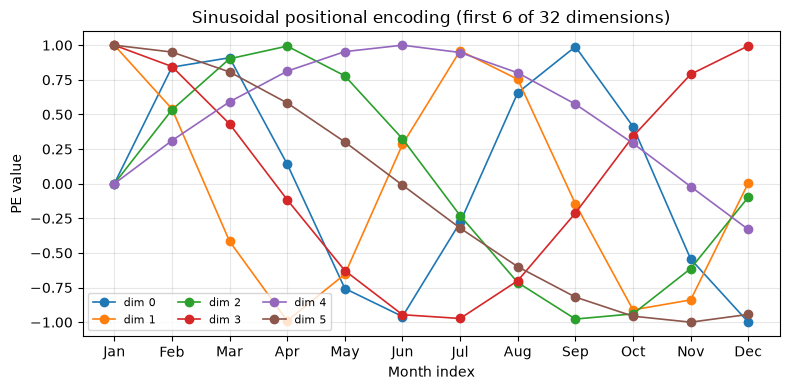

In [7]:
# Sinusoidal PE (Vaswani et al., 2017): attention has no inherent order
pe = _sinusoidal_positional_encoding(max_len=12, dim=32)
print(f"PE shape : {tuple(pe.shape)}  (months x hidden_dim)")
print(f"PE range  : [{pe.min():.3f}, {pe.max():.3f}]")

fig, ax = plt.subplots(figsize=(8, 4))
for d in range(6):
    ax.plot(range(12), pe[:, d].numpy(), marker="o", linewidth=1.2, label=f"dim {d}")
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_xlabel("Month index")
ax.set_ylabel("PE value")
ax.set_title("Sinusoidal positional encoding (first 6 of 32 dimensions)")
ax.legend(ncol=3, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# One spatial attention step and one STTN / GMAN block
n_demo = 8
demo_xy = coords[:n_demo]
e_idx, _ = _knn_edges(demo_xy, k=3)
x = torch.randn(n_demo, 8)
attn = GraphMultiHeadAttention(dim=8, n_heads=2)
h_attn = attn(x, e_idx, n_nodes=n_demo)

h_seq = torch.randn(5, n_demo, 8)  # (T, n_nodes, dim)
h_sttn = SpatialTemporalBlock(dim=8, n_heads=2, dropout=0.0)(h_seq, e_idx, n_nodes=n_demo)
h_gman = GatedFusionBlock(dim=8, n_heads=2, dropout=0.0)(h_seq, e_idx, n_nodes=n_demo)

print(f"GraphMHA out     : {tuple(h_attn.shape)}, finite={bool(torch.isfinite(h_attn).all())}")
print(f"STTN block out   : {tuple(h_sttn.shape)}, finite={bool(torch.isfinite(h_sttn).all())}")
print(f"GMAN block out   : {tuple(h_gman.shape)}, finite={bool(torch.isfinite(h_gman).all())}")
print(
    f"STGTN aliases    : STTN subclass={issubclass(STTN, STGTNRegressionKriging)}, "
    f"GMAN subclass={issubclass(GMAN, STGTNRegressionKriging)}"
)


GraphMHA out     : (8, 8), finite=True
STTN block out   : (5, 8, 8), finite=True
GMAN block out   : (5, 8, 8), finite=True
STGTN aliases    : STTN subclass=True, GMAN subclass=True



***
## 6. Hold-Out Station Split

To test genuine spatial-temporal *extrapolation* (not just interpolating a missing month at a known site), we hold out **25 stations with complete 12-month coverage** entirely. Every month at those sites is predicted from the remaining 138 stations. The 7 stations with partial-year coverage stay in the training set: `STTN.fit` / `GMAN.fit` already allow NaN. This split (seed=0, `n_test=25`) is the same protocol as `pygstat.krigeST` and `tests/test_kriging_STGTN.py`.


Train : 138 stations, 1635 site-months
Test  : 25 stations (held out), 300 site-months


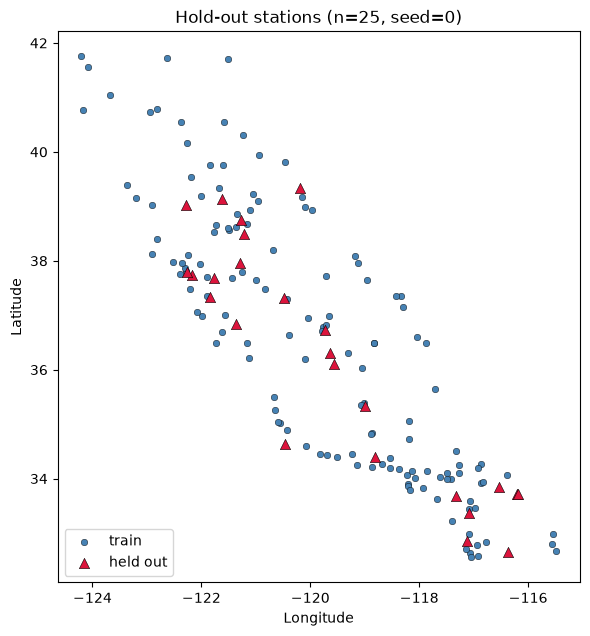

In [9]:
rng = np.random.default_rng(0)
test_idx = rng.choice(complete, size=25, replace=False)
train_mask = np.ones(len(values), dtype=bool)
train_mask[test_idx] = False

coords_train, values_train = coords[train_mask], values[train_mask]
coords_test, values_test = coords[test_idx], values[test_idx]
latlon_train = latlon.iloc[np.flatnonzero(train_mask)]
latlon_test = latlon.iloc[test_idx]

print(f"Train : {train_mask.sum()} stations, {int(np.isfinite(values_train).sum())} site-months")
print(f"Test  : {len(test_idx)} stations (held out), {int(np.isfinite(values_test).sum())} site-months")

fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(
    latlon_train["lon"], latlon_train["lat"],
    s=22, c="steelblue", edgecolor="k", linewidth=0.3, label="train",
)
ax.scatter(
    latlon_test["lon"], latlon_test["lat"],
    s=55, c="crimson", marker="^", edgecolor="k", linewidth=0.4, label="held out",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hold-out stations (n=25, seed=0)")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()



***
## 7. Fit STTN and GMAN

Both families are fit on the **training stations only**. Hyperparameters match `tests/test_kriging_STGTN.py`: `k_neighbors=8`, `hidden_dim=32`, `n_heads=4`, `n_layers=2`, `max_epochs=300`, `patience=30`. A random 15% of training stations are held out internally for early stopping (`val_fraction=0.15`). Residual ordinary kriging uses a spherical variogram, independently per month.

`seed=` controls the (station, time) masking pattern, not PyTorch's global weight-init RNG, so exact numbers vary a little run to run — the same caveat as TGCN/DCRNN and ConvLSTM.


In [10]:
COMMON = dict(
    k_neighbors=8,
    hidden_dim=32,
    n_heads=4,
    n_layers=2,
    max_epochs=300,
    patience=30,
    device=DEVICE,
    seed=0,
)

specs = {
    "sttn": STTN,
    "gman": GMAN,
}

fitted = {}
for name, cls in specs.items():
    print()
    print(f"===== {name.upper()} =====")
    rk = cls(**COMMON)
    rk.fit(coords_train, values_train, verbose=True)
    fitted[name] = rk
    print()
    print(rk)
    print(f"Epochs run     : {len(rk.train_losses_)}")
    print(f"Best val loss  : {min(rk.val_losses_):.6f}")
    print(f"Months with OK : {sorted(rk.krige_by_step_)}")



===== STTN =====


Epoch 1/300 - Train Loss: 1.101865, Val Loss: 1.186697
Epoch 2/300 - Train Loss: 1.300301, Val Loss: 0.933000


Epoch 3/300 - Train Loss: 1.073553, Val Loss: 0.809167
Epoch 4/300 - Train Loss: 0.676885, Val Loss: 0.783993


Epoch 5/300 - Train Loss: 1.013728, Val Loss: 0.740006
Epoch 6/300 - Train Loss: 0.927526, Val Loss: 0.739523


Epoch 7/300 - Train Loss: 0.689372, Val Loss: 0.752404
Epoch 8/300 - Train Loss: 0.692868, Val Loss: 0.711626


...

Epoch 52/300 - Train Loss: 0.271943, Val Loss: 0.573602
Epoch 53/300 - Train Loss: 0.371506, Val Loss: 0.574835


Epoch 54/300 - Train Loss: 0.422737, Val Loss: 0.558215
Epoch 55/300 - Train Loss: 0.277249, Val Loss: 0.552185


Epoch 56/300 - Train Loss: 0.375546, Val Loss: 0.544308
Epoch 57/300 - Train Loss: 0.341586, Val Loss: 0.544814


Epoch 58/300 - Train Loss: 0.311657, Val Loss: 0.548261
Epoch 59/300 - Train Loss: 0.303115, Val Loss: 0.560060



GMAN(block_type='gman', k_neighbors=8, fitted)
Epochs run     : 60
Best val loss  : 0.470911
Months with OK : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



***
## 8. Training Curves

Validation loss is the early-stopping signal: a held-out fraction of *training* stations is fully excluded from the graph input at every epoch, so the curve measures reconstruction at locations the Transformer never saw as observed values.


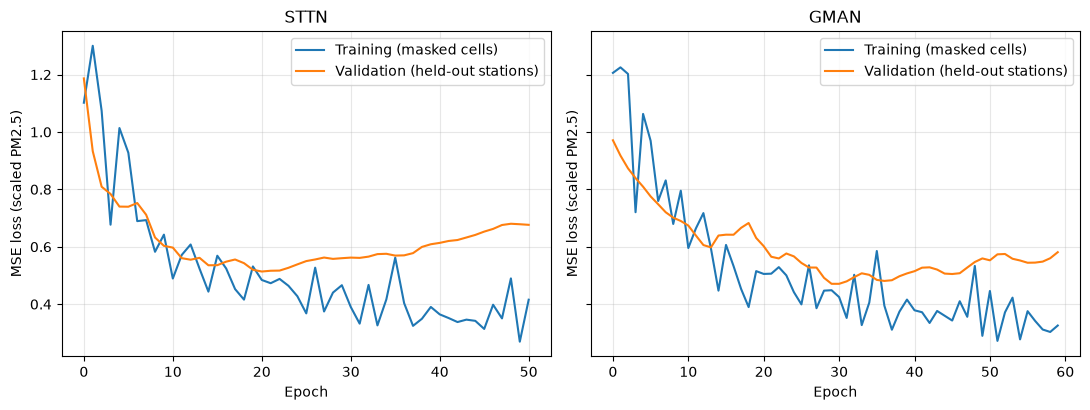

In [11]:
n = len(fitted)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.2), sharey=True)
if n == 1:
    axes = [axes]
for ax, (name, rk) in zip(axes, fitted.items()):
    ax.plot(rk.train_losses_, label="Training (masked cells)")
    ax.plot(rk.val_losses_, label="Validation (held-out stations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (scaled PM2.5)")
    ax.set_title(name.upper())
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



***
## 9. Validate on Held-Out Stations

Predict every station-month of the 25 held-out stations from each trained ST-GTN + residual kriging, and compare against a **naive baseline**: the overall training-mean PM2.5. Classical space-time Ordinary Kriging on this exact split scores RMSE ≈ 2.24 µg/m³ ($R^2$ ≈ 0.58). Development runs of this test had STTN at RMSE ≈ 2.10 ($R^2$ ≈ 0.63) and GMAN at ≈ 2.44 ($R^2$ ≈ 0.51), both competitive with TGCN/DCRNN. Exact numbers move a little because weight initialization is not pinned.


In [12]:
train_mean = float(np.nanmean(values_train))
obs_mask_test = ~np.isnan(values_test)
y_obs = values_test[obs_mask_test]
baseline_rmse = float(np.sqrt(mean_squared_error(y_obs, np.full_like(y_obs, train_mean))))

rows = []
pred_lookup = {}
for name, rk in fitted.items():
    y_hat_full, y_std_full = rk.predict(coords_test, return_std=True)
    y_hat = y_hat_full[obs_mask_test]
    pred_lookup[name] = {"y_pred": y_hat_full, "y_std": y_std_full}
    rmse = float(np.sqrt(mean_squared_error(y_obs, y_hat)))
    rows.append({
        "family": name,
        "class": type(rk).__name__,
        "k_neighbors": rk.k_neighbors,
        "hidden_dim": rk.hidden_dim,
        "n_heads": rk.n_heads,
        "n_layers": rk.n_layers,
        "epochs": len(rk.train_losses_),
        "test_rmse": rmse,
        "test_mae": float(mean_absolute_error(y_obs, y_hat)),
        "test_r2": float(r2_score(y_obs, y_hat)),
        "test_me": float((y_obs - y_hat).mean()),
        "rmse_vs_baseline": rmse / baseline_rmse,
        "mean_se": float(y_std_full[obs_mask_test].mean()),
    })

results = pd.DataFrame(rows).set_index("family")
print(f"Naive-mean baseline RMSE = {baseline_rmse:.3f} ug/m3")
display(results.round(3))
best_name = results["test_rmse"].idxmin()
print(f"Best held-out family: {best_name}  (RMSE={results.loc[best_name, 'test_rmse']:.3f})")


Naive-mean baseline RMSE = 3.461 ug/m3


,class,k_neighbors,hidden_dim,n_heads,n_layers,epochs,test_rmse,test_mae,test_r2,test_me,rmse_vs_baseline,mean_se
family,,,,,,,,,,,,
sttn,STTN,8,32,4,2,51,2.123,1.665,0.621,0.276,0.613,2.715
gman,GMAN,8,32,4,2,60,2.347,1.819,0.537,0.407,0.678,2.680


Best held-out family: sttn  (RMSE=2.123)


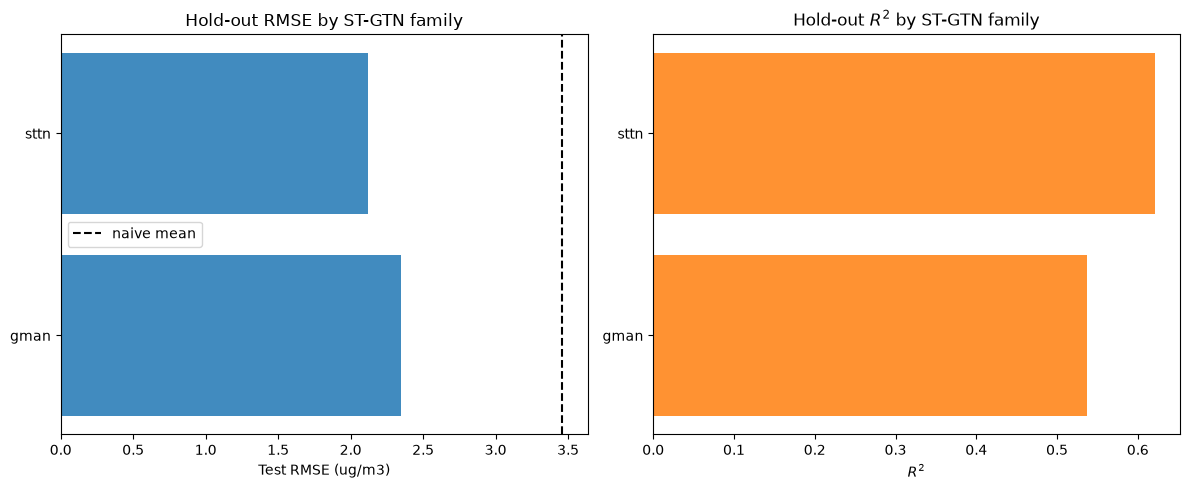

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = results.sort_values("test_rmse")
axes[0].barh(order.index, order["test_rmse"], color="C0", alpha=0.85)
axes[0].axvline(baseline_rmse, color="k", linestyle="--", label="naive mean")
axes[0].set_xlabel("Test RMSE (ug/m3)")
axes[0].set_title("Hold-out RMSE by ST-GTN family")
axes[0].invert_yaxis()
axes[0].legend()

axes[1].barh(order.index, order["test_r2"], color="C1", alpha=0.85)
axes[1].set_xlabel("$R^2$")
axes[1].set_title("Hold-out $R^2$ by ST-GTN family")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


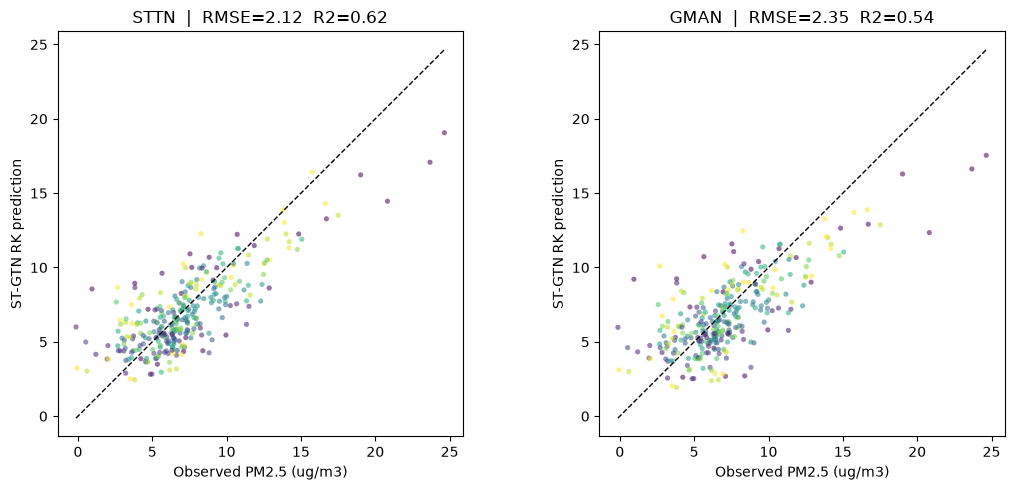

In [14]:
show = list(fitted)
fig, axes = plt.subplots(1, len(show), figsize=(5.5 * len(show), 5.0))
if len(show) == 1:
    axes = [axes]
lims = [
    min(y_obs.min(), min(pred_lookup[n]["y_pred"][obs_mask_test].min() for n in show)),
    max(y_obs.max(), max(pred_lookup[n]["y_pred"][obs_mask_test].max() for n in show)),
]
month_of = np.where(obs_mask_test)[1]
for ax, name in zip(axes, show):
    y_hat = pred_lookup[name]["y_pred"][obs_mask_test]
    rmse = results.loc[name, "test_rmse"]
    r2 = results.loc[name, "test_r2"]
    ax.scatter(y_obs, y_hat, s=14, alpha=0.55, c=month_of, cmap="viridis", edgecolor="none")
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("Observed PM2.5 (ug/m3)")
    ax.set_ylabel("ST-GTN RK prediction")
    ax.set_title(f"{name.upper()}  |  RMSE={rmse:.2f}  R2={r2:.2f}")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


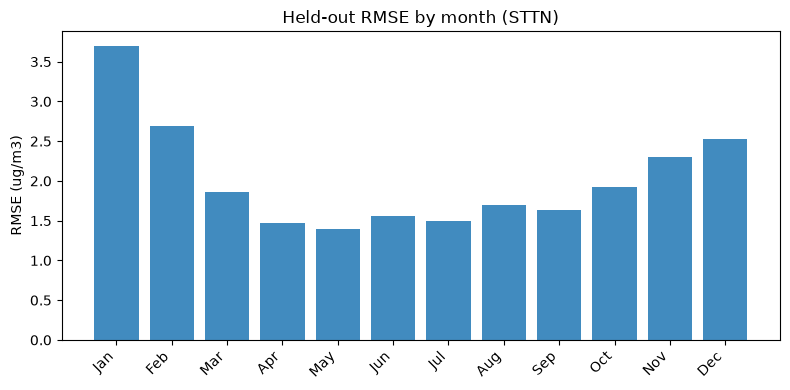

In [15]:
best_pred = pred_lookup[best_name]["y_pred"]
rmse_by_month = []
for m in range(12):
    m_obs = values_test[:, m]
    m_hat = best_pred[:, m]
    keep = ~np.isnan(m_obs)
    rmse_by_month.append(float(np.sqrt(np.mean((m_obs[keep] - m_hat[keep]) ** 2))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(12), rmse_by_month, color="C0", alpha=0.85)
ax.set_xticks(range(12), MONTH_NAMES, rotation=45, ha="right")
ax.set_ylabel("RMSE (ug/m3)")
ax.set_title(f"Held-out RMSE by month ({best_name.upper()})")
plt.tight_layout()
plt.show()


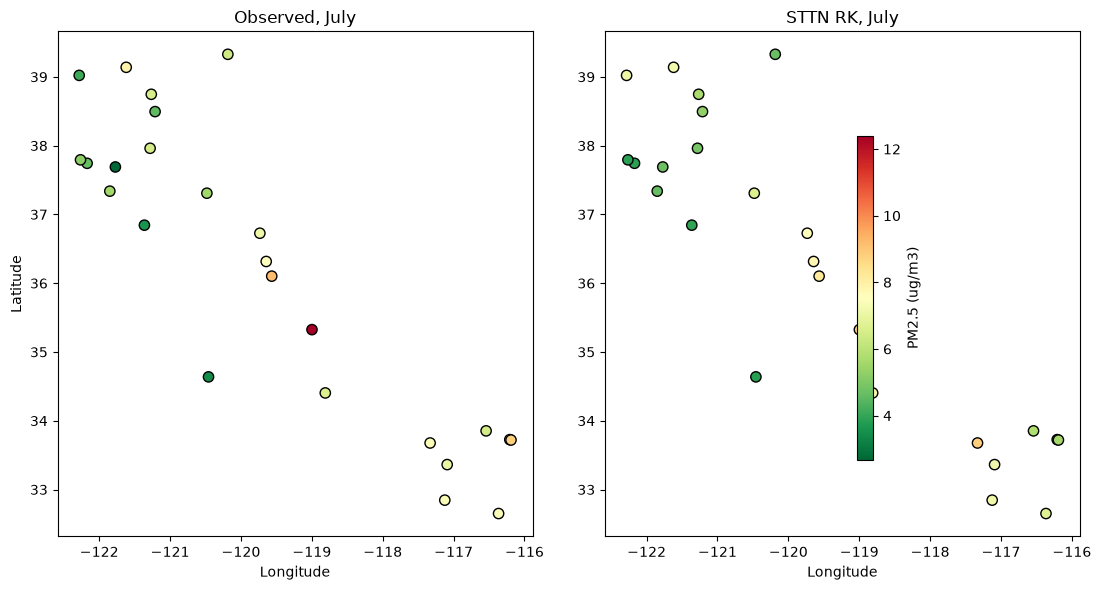

In [16]:
snap_m = 6
vmin = np.nanmin([values_test[:, snap_m].min(), best_pred[:, snap_m].min()])
vmax = np.nanmax([values_test[:, snap_m].max(), best_pred[:, snap_m].max()])
fig, axj = plt.subplots(1, 2, figsize=(11, 6))
axj[0].scatter(
    latlon_test["lon"], latlon_test["lat"], c=values_test[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
axj[0].set_title("Observed, July")
axj[0].set_xlabel("Longitude")
axj[0].set_ylabel("Latitude")
s1 = axj[1].scatter(
    latlon_test["lon"], latlon_test["lat"], c=best_pred[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
axj[1].set_title(f"{best_name.upper()} RK, July")
axj[1].set_xlabel("Longitude")
plt.colorbar(s1, ax=axj, label="PM2.5 (ug/m3)", shrink=0.7)
plt.tight_layout()
plt.show()



If RMSE is well below the naive-mean baseline, spatial and temporal attention (plus residual kriging) are doing real work: nearby stations and nearby months are informing the prediction. Residual RMSE that varies by month usually tracks the seasonal amplitude of PM2.5 (winter is harder).



***
## 10. Residual Variograms

A spherical variogram is fit independently at each month on each model's out-of-fold residuals. A better neighborhood-aware trend typically leaves **less structured** residual spatial variation (smaller sill / shorter range). January (peak winter PM2.5) and July are shown for the best family.


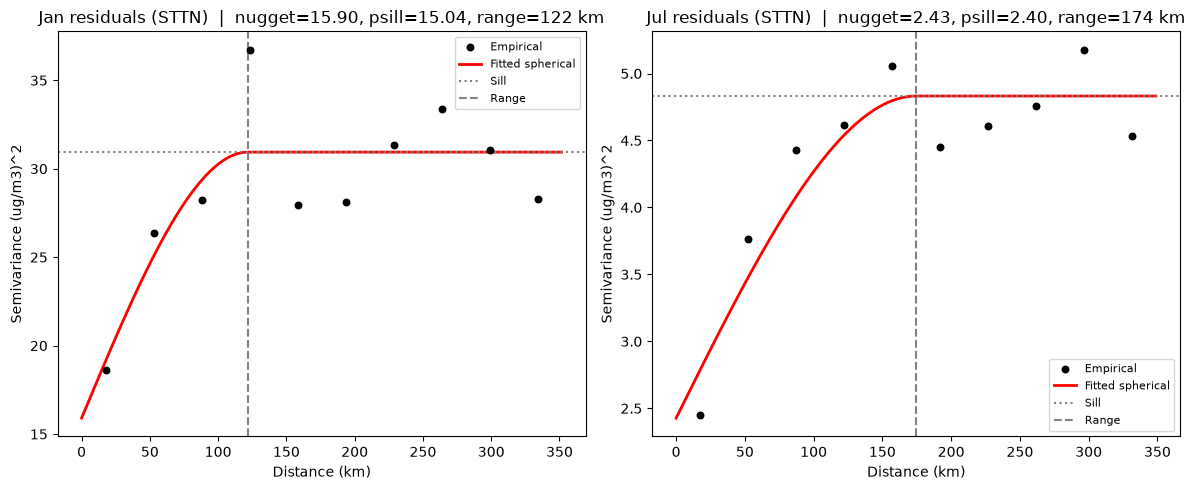

In [17]:
rk_best = fitted[best_name]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, month in zip(axes, [0, 6]):
    krige = rk_best.krige_by_step_[month]
    vg_r = krige.variogram
    nugget, psill, rng_m = vg_r.fitted_params
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags / 1000, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine / 1000, vg_r(h_fine), color="red", linewidth=2, label="Fitted spherical")
    ax.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
    ax.axvline(rng_m / 1000, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Semivariance (ug/m3)^2")
    ax.set_title(
        f"{MONTH_NAMES[month]} residuals ({best_name.upper()})  |  "
        f"nugget={nugget:.2f}, psill={psill:.2f}, range={rng_m/1000:.0f} km"
    )
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



***
## 11. Predict on the California Grid

For a production map we **refit both families on the full 163-station panel** (rather than the train/test split), then predict at every cell of `data/CA_pm25_grid_predictions.csv` — the same 5 km California grid used by classical space-time Ordinary Kriging in Tutorial 13. Query cells attach inductively to the training graph. `predict(..., return_std=True)` returns the residual-kriging standard error (not a Transformer posterior).


In [18]:
grid = pd.read_csv(DATA_DIR / "CA_pm25_grid_predictions.csv")
grid_xy = grid.loc[grid["month"] == 0, ["x", "y"]].to_numpy()
print(f"Reference grid : {len(grid):,} rows  ({len(grid_xy):,} cells x 12 months)")
print(f"Columns        : {list(grid.columns)}")
print(f"Cell spacing   : ~{np.diff(np.sort(np.unique(grid_xy[:, 0]))).min():.0f} m")
grid.head()


Reference grid : 196,764 rows  (16,397 cells x 12 months)
Columns        : ['x', 'y', 'month', 'month_name', 'pm25_pred', 'pm25_sd']
Cell spacing   : ~5000 m


,x,y,month,month_name,pm25_pred,pm25_sd
0,273523.871,-602012.650,0,Jan,19.379,0.659
1,278523.871,-602012.650,0,Jan,21.009,0.306
2,283523.871,-602012.650,0,Jan,19.348,0.622
3,288523.871,-602012.650,0,Jan,18.211,0.571
4,273523.871,-597012.650,0,Jan,15.707,0.607


In [19]:
fitted_full = {}
pred_full = {}
std_full = {}
for name, cls in specs.items():
    print()
    print(f"===== {name.upper()} (full panel) =====")
    rk = cls(**COMMON)
    rk.fit(coords, values, verbose=True)
    pred, std = rk.predict(grid_xy, return_std=True)
    fitted_full[name] = rk
    pred_full[name] = pred
    std_full[name] = std
    print()
    print(f"Grid prediction shape : {pred.shape}")
    print(f"Finite predictions     : {np.isfinite(pred).all()}")
    print(f"PM2.5 pred mean / max  : {pred.mean():.2f} / {pred.max():.2f} ug/m3")
    print(f"SE mean / max          : {std.mean():.2f} / {std.max():.2f} ug/m3")



===== STTN (full panel) =====
Epoch 1/300 - Train Loss: 1.227318, Val Loss: 1.421747


Epoch 2/300 - Train Loss: 1.255145, Val Loss: 1.168963
Epoch 3/300 - Train Loss: 1.097342, Val Loss: 0.987940


Epoch 4/300 - Train Loss: 0.807838, Val Loss: 0.983956
Epoch 5/300 - Train Loss: 0.987736, Val Loss: 0.966709


Epoch 6/300 - Train Loss: 1.043803, Val Loss: 0.896878
Epoch 7/300 - Train Loss: 0.670759, Val Loss: 0.866908


Epoch 8/300 - Train Loss: 0.716691, Val Loss: 0.886187
Epoch 9/300 - Train Loss: 0.575513, Val Loss: 0.885776


...

Epoch 61/300 - Train Loss: 0.329377, Val Loss: 0.758033
Epoch 62/300 - Train Loss: 0.352138, Val Loss: 0.760075


Epoch 63/300 - Train Loss: 0.427706, Val Loss: 0.760337
Epoch 64/300 - Train Loss: 0.262401, Val Loss: 0.764415


Epoch 65/300 - Train Loss: 0.363894, Val Loss: 0.767928
Epoch 66/300 - Train Loss: 0.299965, Val Loss: 0.772516


Epoch 67/300 - Train Loss: 0.270326, Val Loss: 0.776738
Epoch 68/300 - Train Loss: 0.275437, Val Loss: 0.780597



Grid prediction shape : (16397, 12)
Finite predictions     : True
PM2.5 pred mean / max  : 6.13 / 28.94 ug/m3
SE mean / max          : 2.71 / 5.50 ug/m3



***
## 12. Compare with Classical ST Kriging

The classical reference in `CA_pm25_grid_predictions.csv` is space-time Ordinary Kriging (`STKriging`, Tutorial 13). Per-month Pearson correlation between that surface and each ST-GTN RK surface is the same check as `tests/test_kriging_STGTN.py`. Graph Transformers typically land around mean $r pprox 0.83$–$0.85$ (range 0.72–0.92 by month) — comparable to TGCN/DCRNN (~0.82–0.88) and tighter than ConvLSTM (~0.73), because the $k$-NN graph preserves exact station topology.


STTN vs classical STKriging: per-month corr = ['0.88', '0.80', '0.77', '0.72', '0.79', '0.84', '0.87', '0.86', '0.84', '0.89', '0.87', '0.87'], mean=0.833
GMAN vs classical STKriging: per-month corr = ['0.86', '0.79', '0.77', '0.73', '0.82', '0.86', '0.88', '0.88', '0.84', '0.89', '0.86', '0.84'], mean=0.835


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,mean
family,,,,,,,,,,,,,
sttn,0.875,0.799,0.770,0.717,0.794,0.843,0.871,0.858,0.839,0.890,0.870,0.870,0.833
gman,0.860,0.787,0.773,0.728,0.815,0.858,0.875,0.883,0.845,0.891,0.865,0.836,0.835


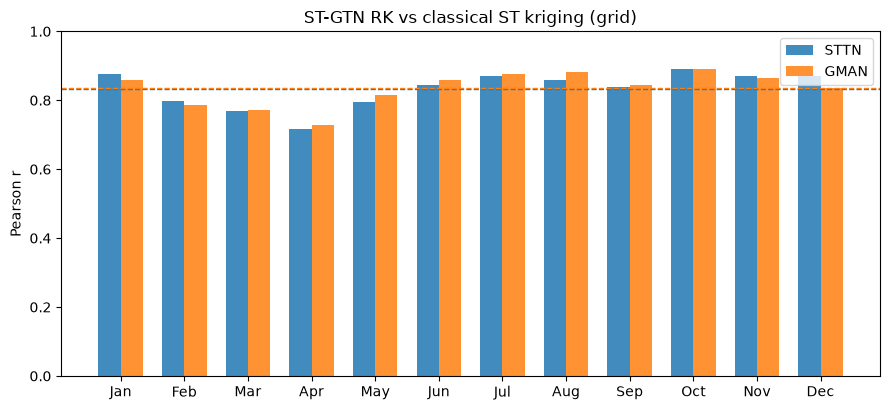

In [20]:
corr_rows = []
corr_lookup = {}
for name, pred in pred_full.items():
    corrs = []
    for month in range(12):
        ref = grid.loc[grid["month"] == month, "pm25_pred"].to_numpy()
        corrs.append(float(np.corrcoef(ref, pred[:, month])[0, 1]))
    corr_lookup[name] = corrs
    mean_corr = float(np.mean(corrs))
    corr_rows.append({"family": name, **{MONTH_NAMES[m]: corrs[m] for m in range(12)}, "mean": mean_corr})
    print(
        f"{name.upper()} vs classical STKriging: per-month corr = "
        f"{[f'{c:.2f}' for c in corrs]}, mean={mean_corr:.3f}"
    )

corr_tbl = pd.DataFrame(corr_rows).set_index("family")
display(corr_tbl.round(3))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(12)
width = 0.35
for i, (name, corrs) in enumerate(corr_lookup.items()):
    ax.bar(x + (i - 0.5) * width, corrs, width, label=name.upper(), alpha=0.85)
    ax.axhline(np.mean(corrs), linestyle="--", color=f"C{i}", linewidth=1)
ax.set_xticks(x, MONTH_NAMES)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.set_title("ST-GTN RK vs classical ST kriging (grid)")
ax.legend()
plt.tight_layout()
plt.show()


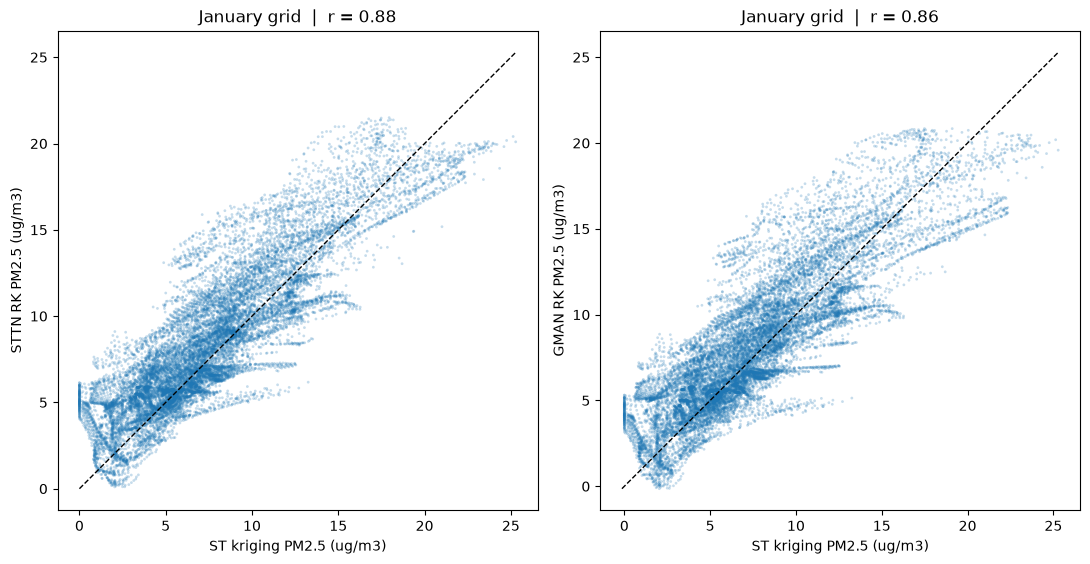

In [21]:
ref_jan = grid.loc[grid["month"] == 0, "pm25_pred"].to_numpy()
fig, axes = plt.subplots(1, len(pred_full), figsize=(5.5 * len(pred_full), 5.5))
if len(pred_full) == 1:
    axes = [axes]
for ax, (name, pred) in zip(np.atleast_1d(axes).ravel(), pred_full.items()):
    hat_jan = pred[:, 0]
    ax.scatter(ref_jan, hat_jan, s=4, alpha=0.25, edgecolor="none")
    lims = [min(ref_jan.min(), hat_jan.min()), max(ref_jan.max(), hat_jan.max())]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("ST kriging PM2.5 (ug/m3)")
    ax.set_ylabel(f"{name.upper()} RK PM2.5 (ug/m3)")
    ax.set_title(f"January grid  |  r = {corr_lookup[name][0]:.2f}")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()



***
## 13. Map Predictions

Monthly surfaces for the **best held-out family**, plus January/July side-by-side with classical ST kriging and the other family. The 5 km grid is clipped to California's boundary (`data/US_STATE.shp`, reprojected to EPSG:3310). Ordinary kriging of residuals has no positivity constraint, so a handful of cells far from stations can go slightly negative; they are clipped to 0 for display, matching Tutorial 13.


In [22]:
ca_states = gpd.read_file(DATA_DIR / "US_STATE.shp")
ca = ca_states[ca_states["STATE"] == "California"].to_crs("EPSG:3310")

best_full = best_name if best_name in pred_full else list(pred_full)[0]
pred_grid = pred_full[best_full]
std_grid = std_full[best_full]
n_clipped = int((pred_grid < 0).sum())
pred_map = np.clip(pred_grid, 0.0, None)
print(f"California boundary : {len(ca)} polygon feature(s), EPSG:3310")
print(f"Mapped family      : {best_full}")
print(f"Clipped negatives  : {n_clipped} / {pred_map.size} cells")

grid_pred = pd.concat(
    [
        pd.DataFrame(
            {
                "x": grid_xy[:, 0],
                "y": grid_xy[:, 1],
                "month": m,
                "month_name": MONTH_NAMES[m],
                "pm25_pred": pred_map[:, m],
                "pm25_sd": std_grid[:, m],
                "pm25_stk": grid.loc[grid["month"] == m, "pm25_pred"].to_numpy(),
                **{
                    f"pm25_{name}": np.clip(pred_full[name][:, m], 0.0, None)
                    for name in pred_full
                },
            }
        )
        for m in range(12)
    ],
    ignore_index=True,
)
display(
    grid_pred.groupby("month_name")["pm25_pred"]
    .agg(["mean", "min", "max"])
    .loc[MONTH_NAMES]
)


California boundary : 1 polygon feature(s), EPSG:3310
Mapped family      : sttn
Clipped negatives  : 79 / 196764 cells


,mean,min,max
month_name,,,
Jan,8.626,0.104,21.500
Feb,5.389,1.930,12.564
Mar,4.516,2.592,7.871
Apr,5.547,3.954,8.749
May,6.167,3.978,10.064
Jun,7.016,4.103,12.939
Jul,6.295,1.843,12.010
Aug,6.927,3.246,13.527
Sep,7.103,1.999,27.972


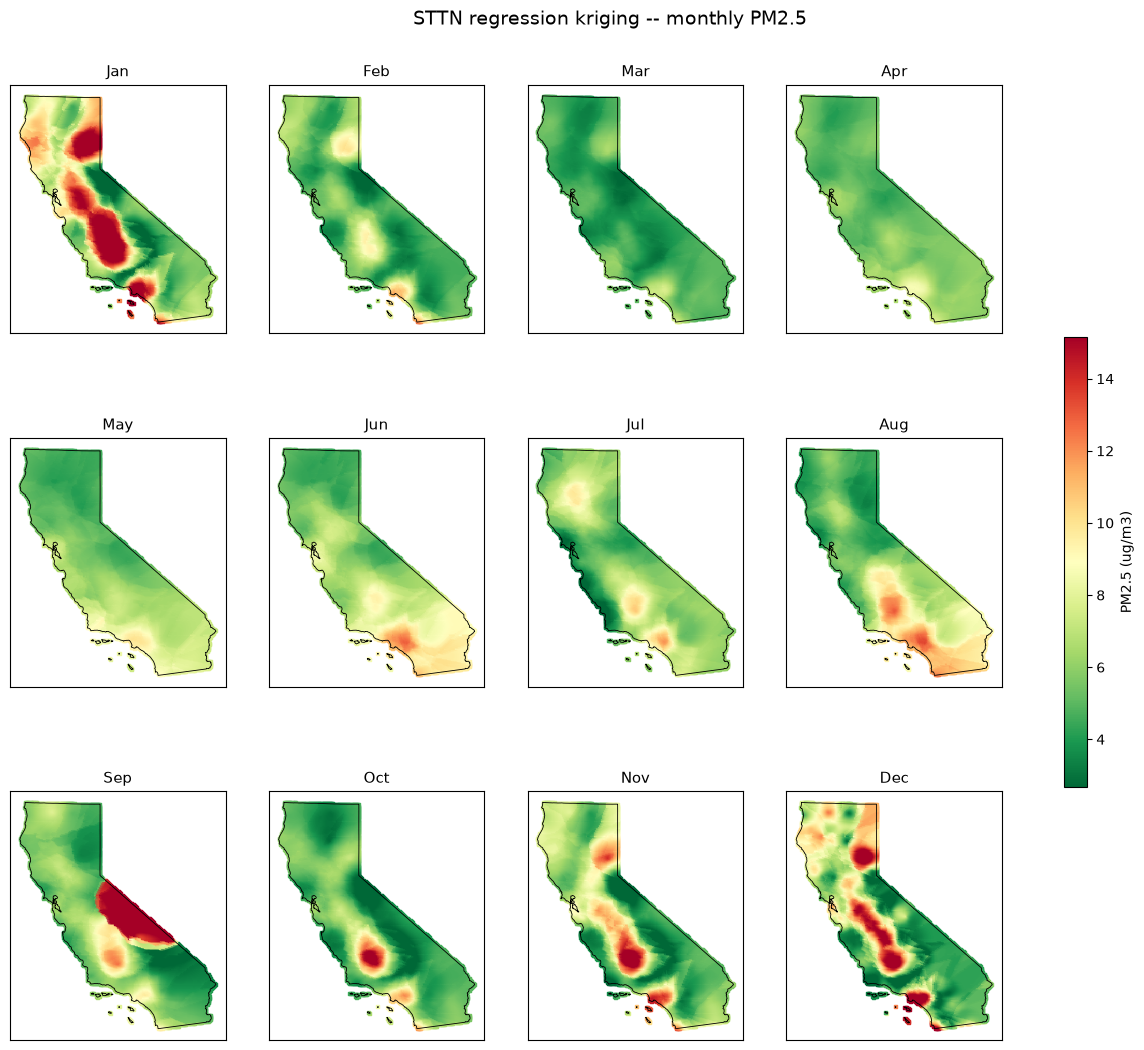

In [23]:
vmin, vmax = grid_pred["pm25_pred"].quantile(0.02), grid_pred["pm25_pred"].quantile(0.98)
fig, axes = plt.subplots(3, 4, figsize=(16, 13), sharex=True, sharey=True)
for m, ax in enumerate(axes.ravel()):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_pred"], cmap="RdYlGn_r",
        vmin=vmin, vmax=vmax, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(MONTH_NAMES[m], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.45, label="PM2.5 (ug/m3)")
fig.suptitle(f"{best_full.upper()} regression kriging -- monthly PM2.5", fontsize=14, y=0.92)
plt.show()


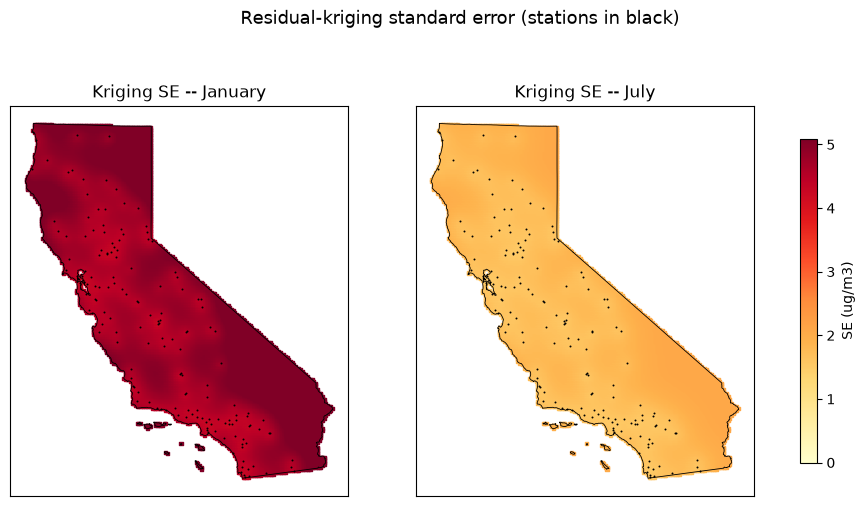

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sd_max = grid_pred["pm25_sd"].quantile(0.98)
for ax, m, title in zip(axes, [0, 6], ["January", "July"]):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_sd"], cmap="YlOrRd",
        vmin=0, vmax=sd_max, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.scatter(coords[:, 0], coords[:, 1], s=8, c="k", marker=".", linewidths=0)
    ax.set_title(f"Kriging SE -- {title}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.7, label="SE (ug/m3)")
fig.suptitle("Residual-kriging standard error (stations in black)", fontsize=13, y=0.98)
plt.show()


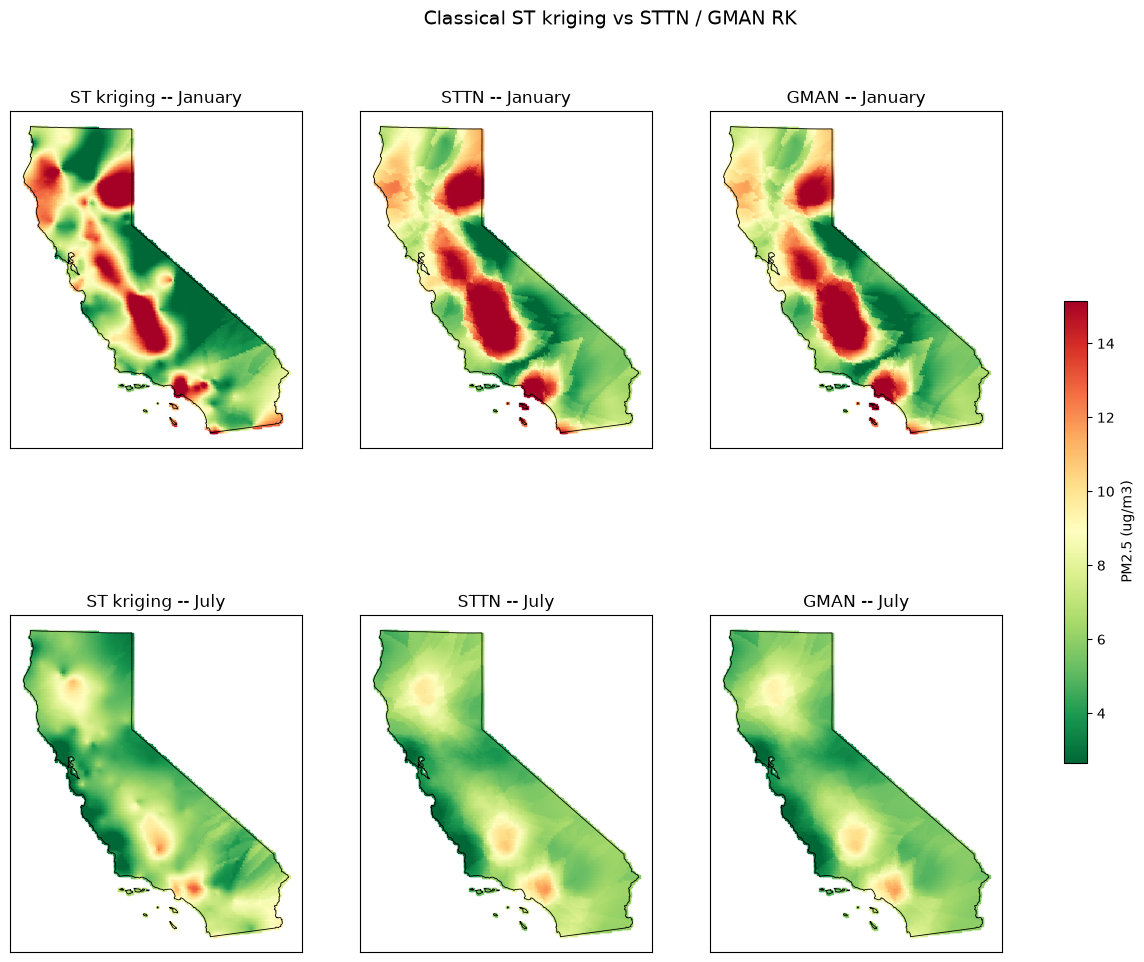

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12), sharex=True, sharey=True)
families = ["pm25_stk"] + [f"pm25_{n}" for n in pred_full]
titles = ["ST kriging"] + [n.upper() for n in pred_full]
for row, (m, month_name) in enumerate([(0, "January"), (6, "July")]):
    sub = grid_pred[grid_pred["month"] == m]
    for col, (colname, title) in enumerate(zip(families, titles)):
        ax = axes[row, col]
        sc = ax.scatter(
            sub["x"], sub["y"], c=sub[colname], cmap="RdYlGn_r",
            vmin=vmin, vmax=vmax, s=4, marker="s",
        )
        ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{title} -- {month_name}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.5, label="PM2.5 (ug/m3)")
fig.suptitle("Classical ST kriging vs STTN / GMAN RK", fontsize=14, y=0.93)
plt.show()



The monthly maps recover the well-known California pattern: winter peaks in the Central Valley, cleaner conditions along the coast, and a summer contrast driven by wildfire and photochemistry. The standard-error maps are high where stations are sparse (eastern deserts, far north) and low in the South Coast and Central Valley networks — a map of **how well the residual kriging is constrained**, not of Transformer epistemic uncertainty. Side-by-side with classical ST kriging, both Transformers track the same regional structure; STTN's sequential spatial-then-temporal attention often stays a little closer to the geostatistical surface than GMAN's gated parallel fusion.


***
## 14. CPU vs GPU STTN Timing

The ~1,600-row CA station panel is too small for a GPU comparison: the STTN
graph is only ~140 training nodes, and host→device copies dominate. Here we
**simulate a CA-like monthly PM2.5 panel** with Sequential Gaussian Simulation
(`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$ space-time
observations, then time **`STTN.fit` + `predict`** on **CPU** (`device='cpu'`)
versus **GPU** (`device='cuda'`). GMAN uses the same engine; we time STTN, the
primary model in this notebook.

Simulation recipe (conditioned on the real 163 stations):

1. Draw $n_{\mathrm{sites}} = 700$ random locations in the California bounding box.
2. Simulate $\log(\mathrm{PM2.5})$ with `sgsim` (exponential variogram, practical range 250 km, conditioned on station-mean PM2.5 from `data/CA_pm25_2025.csv`) and back-transform with $\exp(\cdot)$.
3. Expand each site across 12 months using the observed statewide monthly relative seasonality, giving $n_{\mathrm{train}} = 8{,}400$ (700 stations × 12 months).
4. Draw a separate prediction set of $(x, y)$ locations (no values needed — the trend only needs coordinates plus the training panel).

The GPU work is **PyTorch training and the STTN forward pass**, not residual ordinary kriging. Residual OK is a dense CPU solve and would dominate at this $n$, so the timing section uses `krige_residuals=False`. At prediction time the query nodes attach to the training graph, so GPU work grows gently with $n_{\mathrm{pred}}$. Epochs are capped at **5** so the comparison isolates device cost; the CA maps in §7 used `max_epochs=300`.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. `match` is **same-weights inference**: a GPU-trained network is copied to CPU and both devices must agree (`np.allclose`). Training itself is not bit-identical across devices. If CUDA cannot run here, the GPU column is skipped.


Simulating 700 CA-like PM2.5 sites with sgsim, then 12 months
  conditioning : 163 station means from data/CA_pm25_2025.csv
  vario        : azimuth=0, nugget=0.009, range=250 km, exponential, log(PM2.5)
  sgsim wall   : 5.1 s  (not included in STTN times)
  simulated PM2.5 : [1.07, 25.30] µg/m³  (CA observed [-0.50, 39.05])

GPU usable : True
Repeats    : 3  (median wall time of STTN fit + predict)
n_train    : 8400  (sgsim CA-like PM2.5 panel, 700 sites × 12 months)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the CA bbox)
settings   : architecture: k_neighbors=8, hidden_dim=32, n_heads=4, 2 layers; max_epochs=5, krige_residuals=False

         dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
CA PM2.5 (sgsim)     8400     500    1933.1     961.1   2.01×   True
CA PM2.5 (sgsim)     8400    1000    1863.9     954.0   1.95×   True
CA PM2.5 (sgsim)     8400    2000    1914.9    1027.4   1.86×   True
CA PM2.5 (sgsim)     8400    4000    1809.7    1036.5   1.

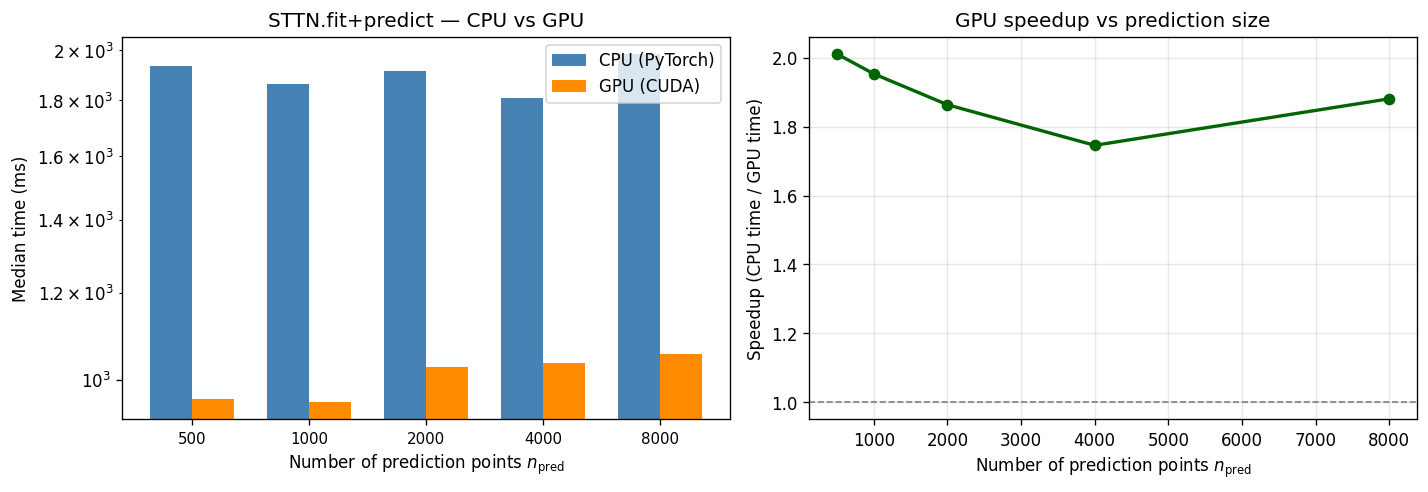

In [21]:
import time

N_REPEATS = 3
N_SITES = 700
N_MONTHS = 12
N_TRAIN = N_SITES * N_MONTHS
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
MAX_EPOCHS = 5
rng_sim = np.random.default_rng(42)

site = panel.groupby("site_id")[["x", "y", "pm25"]].mean().reset_index()
month_factor = panel.groupby("month")["pm25"].mean()
month_factor = (month_factor / month_factor.mean()).to_numpy()

pad = 15_000.0
xmin, xmax = float(panel["x"].min()) - pad, float(panel["x"].max()) + pad
ymin, ymax = float(panel["y"].min()) - pad, float(panel["y"].max()) + pad
xy_sites = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_SITES, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": site["x"].to_numpy(),
    "y": site["y"].to_numpy(),
    "log_pm25": np.log(np.maximum(site["pm25"].to_numpy(), 0.1)),
})
log_var = float(np.var(df_cond["log_pm25"]))
vario_sgs = [0, 0.05 * log_var, 250_000.0, 250_000.0, log_var, "exponential"]

print(f"Simulating {N_SITES:,} CA-like PM2.5 sites with sgsim, then {N_MONTHS} months")
print(f"  conditioning : {len(site)} station means from data/CA_pm25_2025.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=250 km, exponential, log(PM2.5)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_sites, df_cond, "x", "y", "log_pm25",
    num_points=12, vario=vario_sgs, radius=500_000.0,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
spatial = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in STTN times)")

values_train = spatial[:, None] * month_factor[None, :]
print(f"  simulated PM2.5 : [{values_train.min():.2f}, {values_train.max():.2f}] µg/m³"
      f"  (CA observed [{panel['pm25'].min():.2f}, {panel['pm25'].max():.2f}])")
print()

USE_CUDA = DEVICE == "cuda"


def _factory(device):
    return STTN(
        k_neighbors=8, hidden_dim=32, n_heads=4, n_layers=2,
        max_epochs=MAX_EPOCHS, patience=20, device=device,
        krige_residuals=False, seed=0,
    )


def _sync(device):
    if device == "cuda":
        torch.cuda.synchronize()


def _time_fit_predict(xy, values, xy_pred, device, repeats=N_REPEATS, warmup=True):
    """Median wall time of STTN.fit + predict (trend only)."""
    def once():
        model = _factory(device)
        model.fit(xy, values, verbose=False)
        _sync(device)
        pred = model.predict(xy_pred)
        _sync(device)
        return model, pred

    if warmup:
        k = min(80, len(xy))
        k_pr = min(40, len(xy_pred))
        m = _factory(device)
        m.fit(xy[:k], values[:k], verbose=False)
        _sync(device)
        m.predict(xy_pred[:k_pr])
        _sync(device)

    times = []
    last_model, last_pred = None, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last_model, last_pred = once()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last_model, last_pred


def _inference_match(model, xy_pred, pred_gpu):
    model.model_.to("cpu")
    model.device_ = torch.device("cpu")
    if hasattr(model, "edge_index_") and model.edge_index_ is not None:
        model.edge_index_ = model.edge_index_.to("cpu")
    pred_cpu = model.predict(xy_pred)
    return bool(np.allclose(pred_gpu, pred_cpu, rtol=1e-3, atol=1e-4, equal_nan=True))


print(f"GPU usable : {USE_CUDA}")
print(f"Repeats    : {N_REPEATS}  (median wall time of STTN fit + predict)")
print(f"n_train    : {N_TRAIN}  (sgsim CA-like PM2.5 panel, {N_SITES} sites × {N_MONTHS} months)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the CA bbox)")
print(f"settings   : architecture: k_neighbors=8, hidden_dim=32, n_heads=4, 2 layers; max_epochs=5, krige_residuals=False")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, _, _ = _time_fit_predict(xy_sites, values_train, xy_pr, "cpu")
    row = {
        "dataset": "CA PM2.5 (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_CUDA:
        gpu_t, gpu_model, pred_gpu = _time_fit_predict(
            xy_sites, values_train, xy_pr, "cuda",
        )
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = _inference_match(gpu_model, xy_pr, pred_gpu)
        torch.cuda.empty_cache()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (PyTorch)", color="steelblue")
if USE_CUDA and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CUDA)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("STTN.fit+predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_CUDA:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


`match = True` means the GPU-trained STTN, evaluated on CPU and on GPU with the **same weights**, agrees to `rtol=1e-3`. The GPU speedup comes from STTN training and the attention forward pass (including inductive $k$-NN attachment of query nodes), not from SGS and not from residual ordinary kriging (turned off here). Fit still dominates at 5 epochs, so the curve is relatively flat in $n_{\mathrm{pred}}$; the GPU stays about 1.8–2.0× faster. Use `device=DEVICE` so the same cells run on a laptop CPU or a CUDA workstation without edits. For the published CA maps, leave `krige_residuals=True` (the default).



***
## 15. Summary and Conclusions

This notebook applied **spatio-temporal graph Transformer regression kriging** to California **monthly PM2.5**, the attention-based counterpart of the recurrent ST-GNNs in Tutorial 15 and of classical `STKriging` (Tutorial 13).

- **Data.** Daily readings at 163 stations (`CA_pm25_2025.csv`) aggregated to a monthly panel in EPSG:3310. The prediction grid is the classical ST-kriging surface in `CA_pm25_grid_predictions.csv`.
- **Trend.** A directed $k$-NN graph (`k_neighbors=8`) plus either sequential spatial-then-temporal Transformer blocks (`STTN`) or parallel spatial + temporal attention fused by a learned gate (`GMAN`). A sinusoidal positional encoding injects month order. New locations attach inductively to training nodes only.
- **Training.** IGNNK-style random masking of (station, month) cells, plus a validation subset of stations always fully excluded.
- **Residuals.** Out-of-fold Transformer reconstructions are kriged spatially, independently per month, and added back.
- **Validation.** The same 25 complete held-out stations as Tutorial 13 / `tests/test_kriging_STGTN.py`. Both families should beat a naive-mean baseline; STTN has come out near classical ST kriging (RMSE ≈ 2.10 vs 2.24 µg/m³) in development runs.
- **Grid.** Per-month correlation with the classical ST-kriging reference is typically $r \approx 0.72$–$0.92$ (mean ~0.83–0.85).

### CPU vs GPU

Timed `STTN.fit` + `predict` on CPU vs GPU using an SGS-simulated CA-like panel ($n_{\mathrm{train}}=8{,}400$), with residual kriging off so the times isolate the neural net.

- **CPU / GPU.** `STTN(..., device=DEVICE)` trains a graph Transformer on PyTorch. GPU work is the network (and inductive $k$-NN attachment at predict time), not residual OK. The 163-station CA panel is too small to show that; §14 uses SGS so $n > 5{,}000$, `krige_residuals=False`, and a short epoch budget.

### When to use ST-GTN RK

- You have a **monitoring network through time** and want a learned spatio-temporal trend plus kriged residuals.
- You want **attention** over neighbors and months (which months matter for this station? which neighbors?) rather than a GRU that compresses history into a single hidden state.
- You do **not** have dense covariates at every prediction cell (this module's trend is the masked panel itself, not external regressors — unlike tutorials 7.1–7.5).

### When not to use it

- A purely spatial snapshot with no time dimension — use ordinary, universal, or regression kriging (tutorials 4–7), or the spatial GNNs in Tutorial 7.5.
- Count / rate data over polygons — use Poisson kriging.
- You prefer a recurrent inductive bias — Tutorial 15 (`TGCN` / `DCRNN`).
- You prefer a CNN on a regular grid — Tutorial 14 (`ConvLSTM`).

### Objects used here

| Object | Role |
|--------|------|
| `pygstat.STTN` | Sequential spatial-then-temporal Transformer + per-month residual OK |
| `pygstat.GMAN` | Parallel spatial + temporal attention, gated fusion + per-month residual OK |
| `pygstat.STGTNRegressionKriging` | Shared engine; `STTN`/`GMAN` pin `block_type` |
| `pygstat.load_ca_pm25_panel` | Daily CA PM2.5 CSV → monthly panel in EPSG:3310 |
| `fit(..., val_fraction=)` | Internal early-stopping split; validation stations are fully excluded from the input |
| `predict(..., return_std=True)` | RK prediction plus residual kriging standard error |
| `train_losses_`, `val_losses_`, `krige_by_step_`, `edge_index_` | Training curves, per-month OK models, and the fitted $k$-NN graph |

Install extras with `pip install pygstat[pytorch]`. Set `device='cuda'` to force a GPU, or leave `device='auto'` (used here via `DEVICE`) to fall back to CPU when CUDA is unavailable. Related tutorials: [13 Spatio-Temporal Kriging](13_krigingST.ipynb), [15 ST-GNN RK](15_kriging_STGNN.ipynb), [14 ConvLSTM RK](14_kriging_CNNLSTM.ipynb), [6.5 GNN RK](06_05_regression_kriging_gnn.ipynb).



***
## 16. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Xu, M., Dai, W., Liu, C., Gao, X., Lin, W., Qi, G.-J. & Xiong, H. (2020). Spatial-Temporal Transformer Networks for Traffic Flow Forecasting. [arXiv:2001.02908](https://arxiv.org/abs/2001.02908) | STTN block used here |
| Zheng, C., Fan, X., Wang, C. & Qi, J. (2020). GMAN: A Graph Multi-Attention Network for Traffic Prediction. *AAAI*. [arXiv:1911.08415](https://arxiv.org/abs/1911.08415) | GMAN gated fusion used here |
| Vaswani, A. et al. (2017). Attention is all you need. *NeurIPS*. | Multi-head attention and sinusoidal PE |
| Dwivedi, V.P. & Bresson, X. (2020). A generalization of Transformer networks to graphs. [arXiv:2012.09699](https://arxiv.org/abs/2012.09699) | Graph-masked attention |
| Wu, Y., Cui, X., Nie, X. & Wang, H. (2021). Inductive Graph Neural Networks for Spatiotemporal Kriging. *AAAI*. | Masked-reconstruction training (IGNNK) |
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | Residual kriging |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences*, 33(10). | RK recipe |
| Pebesma, E. (2012). spacetime: Spatio-Temporal Data in R. *Journal of Statistical Software*, 51(7). | Classical ST kriging reference (`STKriging`) |

### In this library

| Object | Role |
|--------|------|
| `pygstat.STTN` / `GMAN` / `STGTNRegressionKriging` | This tutorial |
| `pygstat.TGCN`, `DCRNN` | Recurrent GNN regression kriging (Tutorial 15) |
| `pygstat.ConvLSTM` | Raster ConvLSTM regression kriging (Tutorial 14) |
| `pygstat.STKriging` | Classical space-time ordinary kriging (Tutorial 13) |
| `pygstat.GNNRegressionKriging`, `KCN`, `IGNNK` | Spatial (no time) GNN RK (Tutorial 7.5) |
| `pygstat.sgsim` | Sequential Gaussian Simulation (used in §14 to build $n>5{,}000$ training data) |
| `tests/test_kriging_STGTN.py` | Unit tests this notebook follows |
| `src/pygstat/kriging_STGTN.py` | Implementation |
| `scripts/predict_ca_pm25_grid.py` | Builds `CA_pm25_grid_predictions.csv` |
